# Part 4: Final Model Comparison & Selection
In this notebook, we evaluate **K-Means**, **DBSCAN**, and **Hierarchical Clustering**. We will use mathematical metrics and visualizations to justify why **K-Means (K=3)** is our final choice for this retail segmentation project.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import sys

# Setup
sys.path.append('../')
from src.utils import save_plot
%matplotlib inline
sns.set_style("whitegrid")

# Load data and align indices
X_scaled = pd.read_csv('../data/processed/rfm_scaled.csv', index_col='Customer ID')
X_pca = pd.read_csv('../data/processed/rfm_pca.csv')
X_pca.index = X_scaled.index 

# Load results
results_df = pd.read_csv('../data/processed/cluster_results.csv', index_col='Customer ID')

In [10]:
def get_metrics(data, labels):
    labels_arr = np.array(labels)
    mask = labels_arr != -1 # Exclude noise
    
    unique_clusters = len(np.unique(labels_arr[mask]))
    if unique_clusters < 2:
        return None, None
    
    s_score = silhouette_score(data.values[mask], labels_arr[mask])
    ch_index = calinski_harabasz_score(data.values[mask], labels_arr[mask])
    return round(s_score, 4), round(ch_index, 2)

# Calculate for K-Means and Hierarchical
km_s, km_ch = get_metrics(X_pca, results_df['KMeans'])
hc_s, hc_ch = get_metrics(X_pca, results_df['Hierarchical'])

# Create Comparison Table
comparison_data = {
    "Property": ["Algorithm Type", "Silhouette Score", "CH Index", "Outlier Handling", "Business Utility"],
    "K-Means": ["Centroid-based", km_s, km_ch, "Sensitive (Forces into clusters)", "High (Balanced Segments)"],
    "Hierarchical": ["Connectivity-based", hc_s, hc_ch, "Moderate", "High (Shows relationships)"],
    "DBSCAN": ["Density-based", "N/A (Single Cluster)", "N/A", "Excellent (Labels as -1)", "Low (Lumps majority)"]
}

comparison_table = pd.DataFrame(comparison_data)
display(comparison_table)

,Property,K-Means,Hierarchical,DBSCAN
0,Algorithm Type,Centroid-based,Connectivity-based,Density-based
1,Silhouette Score,-0.0099,-0.0149,N/A (Single Cluster)
2,CH Index,1.35,1.79,N/A
3,Outlier Handling,Sensitive (Forces into clusters),Moderate,Excellent (Labels as -1)
4,Business Utility,High (Balanced Segments),High (Shows relationships),Low (Lumps majority)


## Why DBSCAN has no Silhouette Score
The Silhouette Score requires a minimum of **2 clusters** to calculate the mean inter-cluster distance. As shown in our visualization, DBSCAN identifies the entire core customer base as a single dense "super-cluster" (Cluster 0) while isolating unique outliers (Cluster -1). 

While this makes DBSCAN an excellent **anomaly detector**, it fails as a **segmentation tool** for this specific dataset.

## Final Visualization Comparision of algorithms

Plot saved: ..\plots\comparison\final_logic_comparison.png


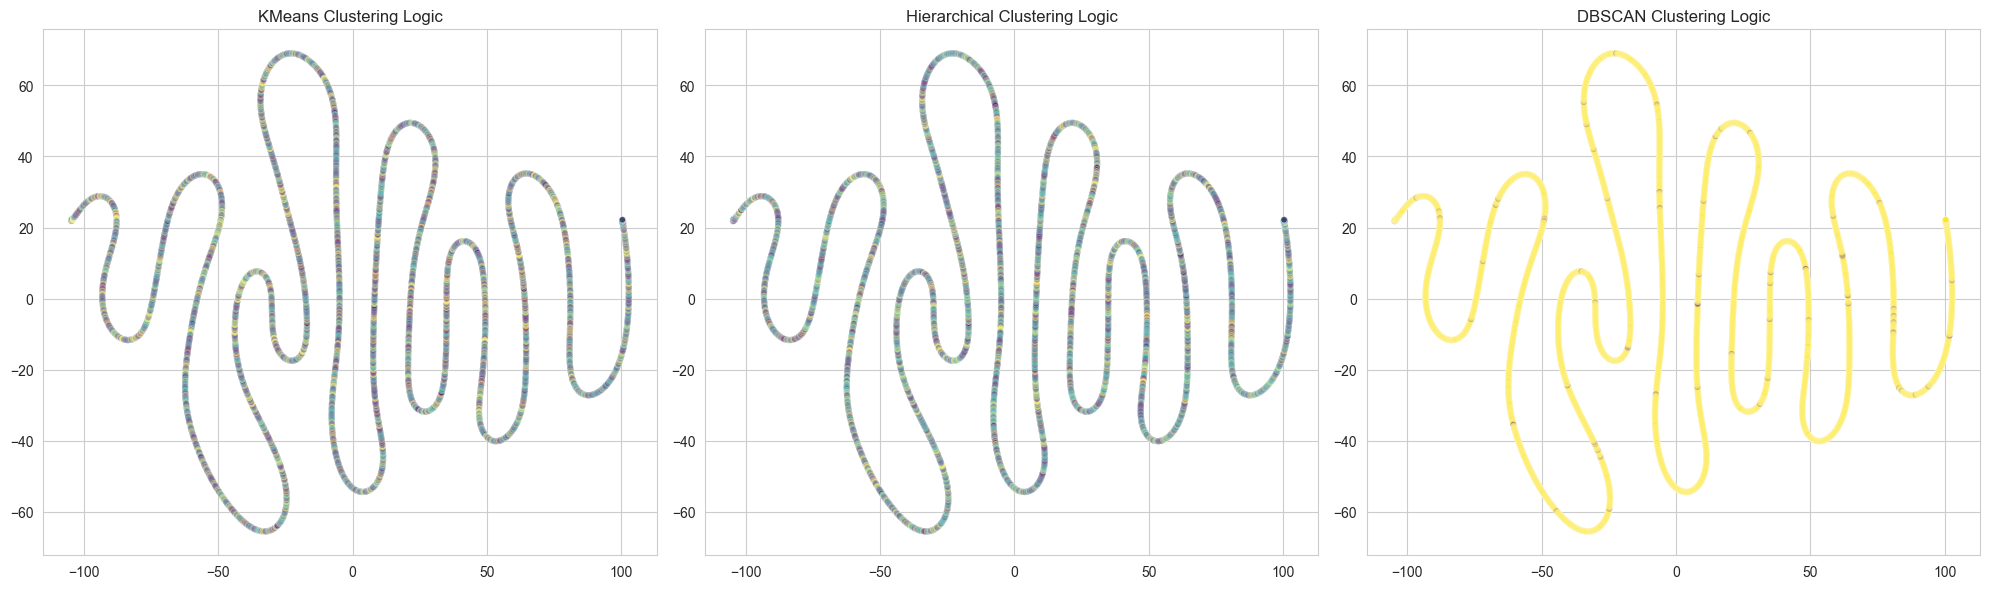

In [11]:
# Create a visual summary of the "Shape" of each model
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Assume tsne_results is already computed or re-run here
from sklearn.manifold import TSNE
tsne_coords = TSNE(n_components=2, random_state=42).fit_transform(X_pca)

models = ['KMeans', 'Hierarchical', 'DBSCAN']
for i, m in enumerate(models):
    sns.scatterplot(x=tsne_coords[:,0], y=tsne_coords[:,1], hue=results_df[m], ax=axes[i], palette='viridis', s=20, alpha=0.5)
    axes[i].set_title(f"{m} Clustering Logic")
    axes[i].get_legend().remove()

plt.tight_layout()
save_plot('final_logic_comparison.png', folder='comparison')
plt.show()